In [1]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
# from wordcloud import WordCloud
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("bbc_news_dataset.csv")
# df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


In [ ]:

# if more than 50% of text is unique --> String
# else --> Category
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() / len(df) < 0.5:
        df[col] = df[col].astype('category')
    else:
        df[col] = df[col].astype('string')

In [4]:
df.info()
df['Category'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   ArticleId  1490 non-null   int64   
 1   Text       1490 non-null   string  
 2   Category   1490 non-null   category
dtypes: category(1), int64(1), string(1)
memory usage: 25.1 KB


['business', 'tech', 'politics', 'sport', 'entertainment']
Categories (5, object): ['business', 'entertainment', 'politics', 'sport', 'tech']

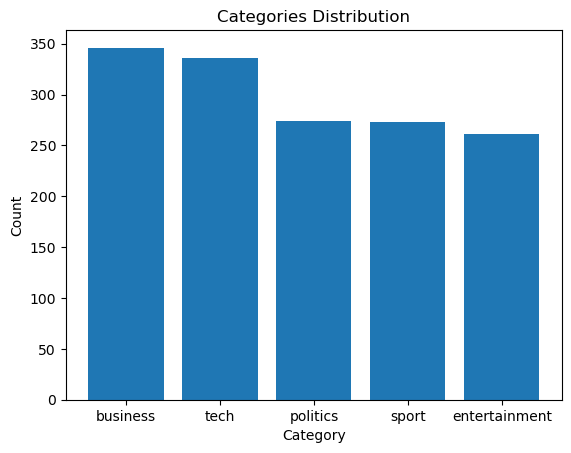

In [6]:
plt.bar(x=df['Category'].unique() ,height=df['Category'].value_counts())
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [7]:
category_names = df['Category'].unique()
value_counts = df['Category'].value_counts()


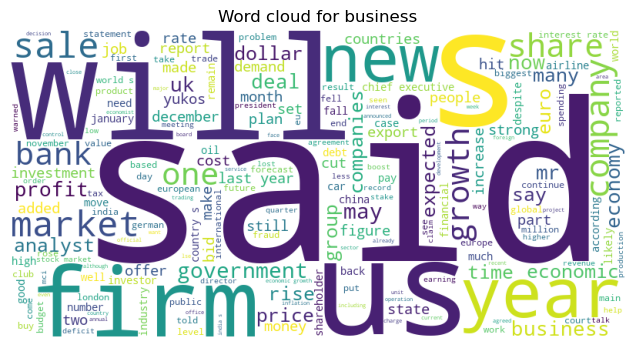

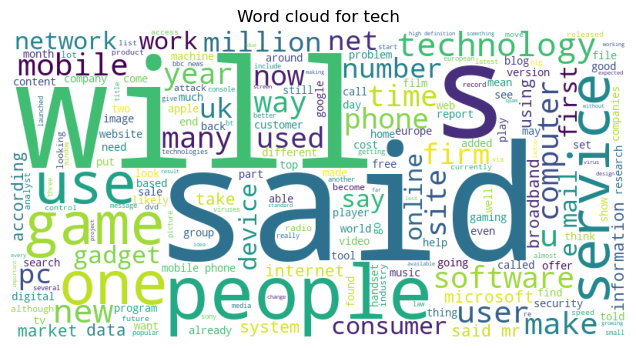

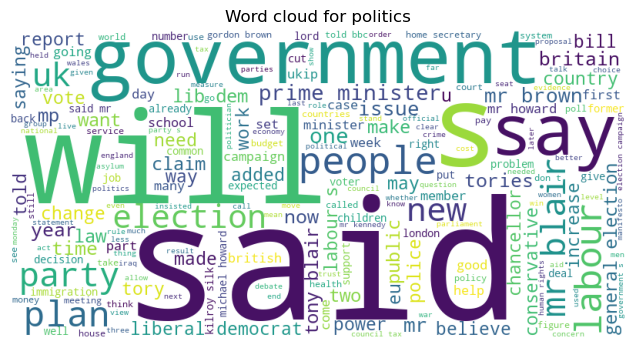

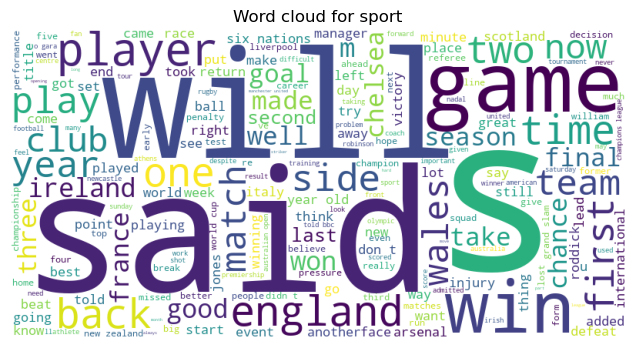

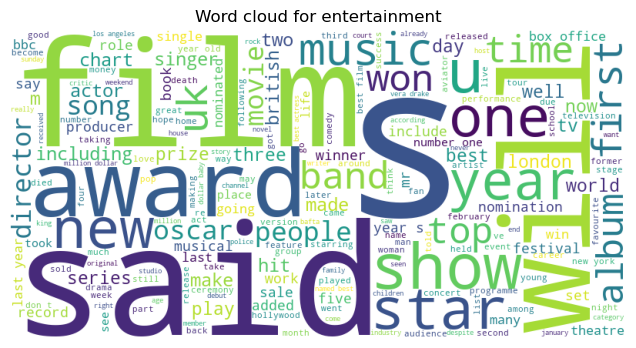

In [8]:
for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,
    background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"Word cloud for {category}")
    plt.show()

In [9]:
X = df['Text']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



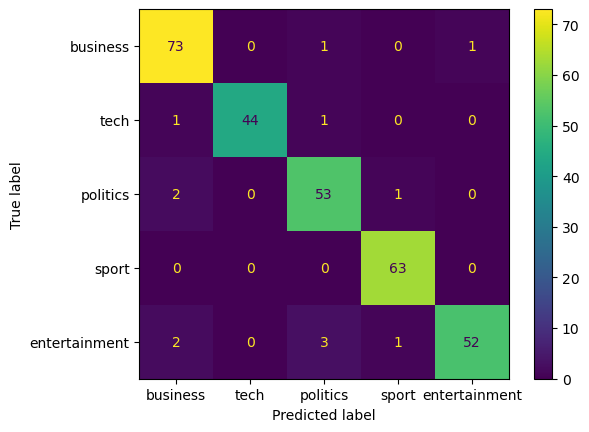

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=category_names).plot()

In [14]:
texts = ['who will win worldcup']
prediction = model.predict(texts)
print(prediction)

['sport']


In [15]:
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS


In [22]:
# tasks 
import joblib
model = joblib.load('model.joblib')
# Task-1. Evaluate the model using Accuracy, Precision, Recall, and F1-Score. Analyze the results.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=category_names))


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("--- Summary Performance Metrics(Overall) ---")
print(f"Overall Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Global Precision : {precision:.4f}")
print(f"Global Recall    : {recall:.4f}")
print(f"Global F1-Score  : {f1:.4f}")


               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
         tech       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
entertainment       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298

--- Summary Performance Metrics(Overall) ---
Overall Accuracy : 0.9564 (95.64%)
Global Precision : 0.9575
Global Recall    : 0.9564
Global F1-Score  : 0.9563


In [28]:
# Task-2. Experiment with TF-IDF parameters such as max_features, ngram_range, and min_df.


experiments = [
    {"name": "Baseline (Default)", "max_features": None, "ngram_range": (1, 1), "min_df": 1},
    {"name": "Limit Vocab Size", "max_features": 1000, "ngram_range": (1, 1), "min_df": 1},
    {"name": "Use Bigrams (Context)", "max_features": None, "ngram_range": (1, 2), "min_df": 1},
    {"name": "Filter Rare Words", "max_features": None, "ngram_range": (1, 1), "min_df": 3},
    {"name": "Aggressive Combo", "max_features": 2000, "ngram_range": (1, 2), "min_df": 2},
]
# ngram_range: means to look for combinations of words.
# max_features: limits the number of features (words) to consider based on their frequency.
# min_df: filters out words that appear in fewer than a specified number of documents.

print(f"{'Experiment Configuration'} | {'Accuracy'}")
print("-" * 40)

# Loop through each experiment setup
for exp in experiments:
    # Build a temporary pipeline with the specific parameters
    test_model = make_pipeline(
        TfidfVectorizer(
            stop_words='english',
            max_features=exp["max_features"],
            ngram_range=exp["ngram_range"],
            min_df=exp["min_df"]
        ),
        MultinomialNB()
    )
    
    # Train and predict
    test_model.fit(X_train, y_train)
    preds = test_model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    # Print results in a neat table format
    print(f"{exp['name']:<25} | {acc * 100:.2f}%")

Experiment Configuration | Accuracy
----------------------------------------
Baseline (Default)        | 95.64%
Limit Vocab Size          | 96.64%
Use Bigrams (Context)     | 96.31%
Filter Rare Words         | 96.64%
Aggressive Combo          | 96.64%


In [35]:
# Task-3. Classify at least five custom news articles and record the predicted categories.
custom_articles = [
    # Article 1: Tech
    "AI is booming.",
    # Article 2: Sport
    "Who will win the world cup?",
    # Article 3: Business
    "Elon Musk is now a trillionaire, due to stock price of Tesla, which has made him the richest person in the world.",    
    # Article 4: Politics
    "Prime Minister vs President.",
    # Article 5: Entertainment
    "A new movie is comming out soon."
]

custom_predictions = model.predict(custom_articles)

for article, prediction in zip(custom_articles, custom_predictions):
    print(f"Prediction: {prediction} -> Text: {article}")

# zip : pairs each article with its prediction

Prediction: business -> Text: AI is booming.
Prediction: sport -> Text: Who will win the world cup?
Prediction: business -> Text: Elon Musk is now a trillionaire, due to stock price of Tesla, which has made him the richest person in the world.
Prediction: politics -> Text: Prime Minister vs President.
Prediction: entertainment -> Text: A new movie is comming out soon.


In [37]:
# Task-4. Save the trained model and reload it to perform predictions on new data

joblib.dump(model, 'model.joblib')
print("Model Saved Successfully!")

reloaded_model = joblib.load('model.joblib')
print("Model reloaded successfully!\n")


new_data = [
    "The tech startup announced a massive breakthrough in AI technology.",
    "The Nepal football team secured a victory."
]

new_predictions = reloaded_model.predict(new_data)

print("--- Predictions from Reloaded Model ---")
for text, pred in zip(new_data, new_predictions):
    print(f"[{pred.upper()}] -> {text[:60]}...")

Model Saved Successfully!
Model reloaded successfully!

--- Predictions from Reloaded Model ---
[TECH] -> The tech startup announced a massive breakthrough in AI tech...
[SPORT] -> The Nepal football team secured a victory....


In [39]:
# Task-5. Experiment with Train-Test Split Ratio
# Task-6. Evaluate the model using different train-test splits:
# 70% – 30% 
# 80% – 20% 
# 90% – 10% 
# Compare the resulting accuracies.

X = df['Text']
y = df['Category']
splits = [
    {"train": "70%", "test": "30%", "test_size": 0.30},
    {"train": "80%", "test": "20%", "test_size": 0.20},
    {"train": "90%", "test": "10%", "test_size": 0.10}
]

print(f"{'Train-Test Split Ratio':<25} | {'Accuracy Score':<15}")
print("-" * 45)
for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=split["test_size"], 
        random_state=42, 
        stratify=y
    )
    # stratifiy=y : means that the split will maintain the same proportion of classes in both training and testing sets.

    split_model = make_pipeline(
        TfidfVectorizer(stop_words='english'),
        MultinomialNB()
    )
    
    
    split_model.fit(X_train, y_train)
    
    predictions = split_model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    

    ratio_label = f"{split['train']} – {split['test']}"
    print(f"{ratio_label:<25} | {accuracy * 100:.2f}%")

Train-Test Split Ratio    | Accuracy Score 
---------------------------------------------
70% – 30%                 | 96.42%
80% – 20%                 | 97.32%
90% – 10%                 | 98.66%


In [42]:
# Task-7. Perform 5-Fold Cross Validation and calculate Mean Accuracy and Standard Deviation .
from sklearn.model_selection import cross_val_score, KFold

cv_model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
# shuffle=True ensures the articles are randomly mixed before splitting

#Calculate accuracies across all 5 individual folds
fold_accuracies = cross_val_score(cv_model, X, y, cv=cv_strategy, scoring='accuracy')

# Calculate Mean and Standard Deviation
mean_accuracy = np.mean(fold_accuracies)
std_deviation = np.std(fold_accuracies)

# 5. Display the final results neatly
print("--- 5-Fold Cross Validation Results---")
for i, acc in enumerate(fold_accuracies, start=1):
    print(f"Fold {i} Accuracy : {acc * 100:.2f}%")

print("-" * 50)
print(f"Mean Accuracy    : {mean_accuracy * 100:.2f}%")
print(f"Standard Dev     : {std_deviation * 100:.2f}%")

--- 5-Fold Cross Validation Results---
Fold 1 Accuracy : 95.64%
Fold 2 Accuracy : 97.32%
Fold 3 Accuracy : 98.32%
Fold 4 Accuracy : 95.30%
Fold 5 Accuracy : 97.32%
--------------------------------------------------
Mean Accuracy    : 96.78%
Standard Dev     : 1.14%


**Task-8. Discuss whether the model is stable across different folds.**

Yes, the model is quite stable among all folds as its accuracy is pretty high(95%+) and standard deviation is also small, which is 1.14%.

In [48]:
# Task-9. Train and prepare a comparison table showing: Accuracy , Training Time , Prediction Time.
# - Multinomial Naïve Bayes
# - Logistic Regression
# - Support Vector Machine (SVM) 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import time

models = {
    "Multinomial Naïve Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": LinearSVC(random_state=42)
}

print(f"{'Model Name':<25} | {'Accuracy':<10} | {'Training Time':<15} | {'Prediction Time':<15}")
print("-" * 75)

for name, classifier in models.items():
    # Create the pipeline
    pipeline = make_pipeline(TfidfVectorizer(stop_words='english'), classifier)
    
    # Benchmark Training Time
    start_train = time.time()
    pipeline.fit(X_train, y_train)
    end_train = time.time()
    training_time = end_train - start_train
    
    # Prediction Time
    start_pred = time.time()
    predictions = pipeline.predict(X_test)
    end_pred = time.time()
    prediction_time = end_pred - start_pred
    
    # Calculate Accuracy
    accuracy = accuracy_score(y_test, predictions)
    
    print(f"{name:<25} | {accuracy * 100:.2f}% | {training_time:.4f}s | {prediction_time:.4f}s")

Model Name                | Accuracy   | Training Time   | Prediction Time
---------------------------------------------------------------------------
Multinomial Naïve Bayes   | 98.66% | 0.6453s | 0.0549s
Logistic Regression       | 99.33% | 0.9850s | 0.0610s
Support Vector Machine    | 97.99% | 0.7761s | 0.0486s


In [55]:
# Task-10. Build a News Recommendation Prototype: After classifying an article, display three similar 
# articles from the same category using cosine similarity.

from sklearn.metrics.pairwise import cosine_similarity

new_df = pd.DataFrame({'text': X, 'category': y})

vectorizer = pipeline.named_steps['tfidfvectorizer']


def get_top_3_recommendations(new_article_text):
    print(f"Input Article: {new_article_text[:80]}...")
    
    # 1. Predict the category of the new article
    predicted_category = pipeline.predict([new_article_text])[0]
    print(f"Predicted Category: {predicted_category} ")
    
    # 2. Filter the dataset to include ONLY articles from the same category
    same_category_df = new_df[ new_df['category'] == predicted_category].copy()
    
    # 3. Convert both the dataset and the input-text into TF-IDF vectors
    # TF-IDF (Term Frequency-Inverse Document Frequency) 
    # : a numerical representation of text that reflects the importance of words in a document relative to a collection of documents.
    dataset_vectors = vectorizer.transform(same_category_df['text'])
    input_text_vector = vectorizer.transform([new_article_text])
    
    # 4. Compute Cosine Similarity between the new article and all candidates
    # .flatten() turns the result into a simple 1D array of scores
    similarity_scores = cosine_similarity(input_text_vector, dataset_vectors).flatten()
    
    # Attach scores to our filtered dataframe
    same_category_df['similarity'] = similarity_scores
    
    # 5. Sort by highest similarity score and grab the top 3
    # We skip the very highest if it's an exact duplicate of the input text
    top_recommendations = same_category_df.sort_values(by='similarity', ascending=False).head(3)
    
    # Display the recommendations
    print("\n Top 3 Similar Recommended Articles:")
    print("-" * 80)
    for index, row in top_recommendations.iterrows():
        print(f"Match Score: {row['similarity']:.4f} | Content: {row['text'][:90]}...")

# --- Test the Recommendation Prototype ---
test_article = "The football manager confirmed that the star winger recovered from his hamstring injury and will start in Saturday's derby match."
get_top_3_recommendations(test_article)

Input Article: The football manager confirmed that the star winger recovered from his hamstring...
Predicted Category: sport 

 Top 3 Similar Recommended Articles:
--------------------------------------------------------------------------------
Match Score: 0.1758 | Content: holmes is hit by hamstring injury kelly holmes has been forced out of this weekend s europ...
Match Score: 0.1322 | Content: wales silent on grand slam talk rhys williams says wales are still not thinking of winning...
Match Score: 0.1141 | Content: o driscoll out of scotland game ireland captain brian o driscoll has been ruled out of sat...


In [56]:
# Task-11. Deploy the trained model using a simple web interface with either Flask or Streamlit and allow 
# users to enter a news article and obtain the predicted category in real time
import streamlit as st
import joblib

# 1. Set up the web page header and styling
st.set_page_config(page_title="AI News Classifier", page_icon="📰", layout="centered")

st.title("📰 Real-Time News Category Classifier")
st.write("Type or paste a news article below to predict its category in real-time.")

# 2. Load your pre-trained pipeline/model safely
@st.cache_resource # This prevents Streamlit from reloading the model file on every single click
def load_trained_model():
    try:
        return joblib.load('model.joblib')
    except FileNotFoundError:
        st.error("⚠️ 'model.joblib' file not found! Please run your training script first to save the model.")
        return None

model = load_trained_model()

# 3. Create the user input interface
user_input = st.text_area("Enter News Article Text:", height=200, placeholder="Paste the content of a news article here...")

# 4. Trigger prediction when the user clicks the button
if st.button("Predict Category", type="primary"):
    if user_input.strip() == "":
        st.warning("⚠️ Please enter some text before clicking predict.")
    elif model is not None:
        with st.spinner("Analyzing text and processing features..."):
            # Predict the class label
            prediction = model.predict([user_input])[0]
            
            # Predict probabilities to show confidence scores
            probabilities = model.predict_proba([user_input])[0]
            class_labels = model.classes_
            
        # 5. Display the results nicely
        st.success(f"🎯 **Predicted Category:** {prediction.upper()}")
        
        # Optional: Display a breakdown of how confident the model is
        st.write("### 📊 Confidence Breakdown:")
        for label, prob in zip(class_labels, probabilities):
            st.write(f"- **{label.capitalize()}**: {prob * 100:.2f}%")
            st.progress(float(prob))

2026-07-05 18:24:29.488 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 18:24:29.491 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 18:24:29.649 
  command:

    streamlit run c:\Users\SABIN\miniconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-05 18:24:29.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 18:24:29.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 18:24:29.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-05 18:24:29.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when run